# [LAB-10] 3. 다중로지스틱회귀

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helper import *

import numpy as np
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('pima_indians_diabetes')
origin.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


## #02. 데이터 품질 검사

### 1. 자료형 점검

- 로지스틱 회귀의 종속변수는 범주형 데이터이다.
  - 값의 종류만 확실히 구분할 수 있다면 숫자타입(int,float)도 상관 없음

In [3]:
df1 = my_qtcheck.set_type(origin, as_category=['Outcome'])


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 48.9 KB


### 2. 중복 검사 및 중복 데이터 삭제

In [4]:
df2 = my_qtcheck.check_duplicates(df1)

중복된 행의 수: 0


### 3. 결측치 확인

In [5]:
df3 = my_qtcheck.check_missing_values(df2)
df3

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
SkinThickness,0,0.000
Insulin,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 4. 연속형 변수의 기술통계량 확인

In [6]:
desc = my_qtcheck.numerical_summary(df2).T
desc

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000
rel_diff,0.282,0.033,0.040,0.107,1.616,0.000,0.267,0.146
rdiff_flag,diff,similar,similar,diff,large_diff,similar,diff,diff


> 최소값이 0인 항목이 다수 발견된다. 의료 데이터에서 수치가 0일 수는 없기 때문에 이 항목을 결측치로 봐야 한다.

### 5. 0값을 결측치로 변경후 결측치 재확인

- 다음의 항목은 0값이 존재할 수 없다.
  - Glucose                   연속형  포도당 부하 검사 수치
  - BloodPressure             연속형  혈압
  - SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
  - Insulin                   연속형  혈청 인슐린
  - BMI                       연속형  체질량 지수
- 하지만 다음의 변수는 해당사항이 없다.
  - 임신횟수(Pregnancies)는 0이 가능한 변수이므로 **반드시 처리 대상에서 제외**해야 한다.
  - 나이(Age)와 당뇨 내력 가중치(DiabetesPedigreeFunction)는 0이 포함되어 있지 않아 처리하더라도 값이 변하지 않는다.

In [7]:
df4 = df2.copy()

# 연속형 컬럼의 이름을 가져와서 반복 순환
for col in df4.select_dtypes(include='number').columns:
    # 컬럼 이름 0값을 포함하는 컬럼인 경우만 처리
    if col not in ['Pregnancies', 'Age']:
        df4[col] = np.where(df4[col] > 0, df4[col], np.nan)

my_qtcheck.check_missing_values(df4)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 6. 결측치 제거

- Glucose(0.7%), BloodPressure(4.6%), BMI(1.4%): 결측치가 5% 미만이므로 **해당 행을 제거**해도 안전하다.
- SkinThickness(29.6%), Insulin(48.7%): 결측치 비율이 과도하게 높으므로 **변수 자체를 제거**한다.
  - 절반 가까이를 중앙값 하나로 대체하면 분산이 인위적으로 줄어 변수가 가진 정보가 사라진다.
- 세 변수의 결측 행을 합치면 **44건(5.7%)이 제거되어 768건 → 724건**이 된다.

In [8]:
# 결측치 비중이 과도하게 높은 컬럼 제거
df5 = df4.drop(columns=['SkinThickness', 'Insulin'])


# 컬럼이 제거된 데이터프레임에서 결측치 비중이 낮은 변수에 대해 행 단위 제거
df5 = df5.dropna().reset_index(drop=True)

# 결측치 제거 결과 확인
my_qtcheck.check_missing_values(df5)

,Missing Count,Missing Ratio (%)
Pregnancies,0,0.000
Glucose,0,0.000
BloodPressure,0,0.000
BMI,0,0.000
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,0,0.000


### 7. 기술 통계량 재확인

- 값이 변경되었으므로 기술 통계량을 다시 산정해야 한다.

In [9]:
desc = my_qtcheck.numerical_summary(df5).T
desc

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
count,724.000,724.000,724.000,724.000,724.000,724.000
mean,3.866,121.883,72.401,32.467,0.475,33.351
std,3.363,30.750,12.380,6.889,0.332,11.765
min,0.000,44.000,24.000,18.200,0.078,21.000
25%,1.000,99.750,64.000,27.500,0.245,24.000
50%,3.000,117.000,72.000,32.400,0.379,29.000
75%,6.000,142.000,80.000,36.600,0.627,41.000
max,17.000,199.000,122.000,67.100,2.420,81.000
rel_diff,0.289,0.042,0.006,0.002,0.253,0.150
rdiff_flag,diff,similar,similar,similar,diff,diff


> **BloodPressure 최솟값 24**: 이완기 혈압 24mmHg는 생존이 어려운 수치이지만 여기서는 0만 결측으로 보고 나머지는 실측으로 인정하여 진행한다.

## #03. 분석용 데이터 전처리

### 이 데이터에서 제외되는 전처리

- 예제 특성에 따른 제외
  - **범주형 독립변수의 라벨링 및 더미변수 처리**
    - 이 예제에는 범주형 독립변수가 없기 때문에  해당되지 않는다.
  - **이상치 대체**
    - 의료 데이터에 대한 이상치는 실제 측정된 수치라 판단하여 처리하지 않기로 결정
- 로지스틱 회귀 특성에 따른 제외
  - **로그변환**
    - 로지스틱 회귀는 독립변수의 정규성을 가정하지 않으므로, 선형회귀와 달리 왜도가 크다는 이유만으로 로그변환을 하지 않는다.
    - 변환이 필요한 경우는 로짓 선형성이 깨졌을 때이며, 그 판단은 다음 단원의 가정 검정에서 다룬다.

### 1. 다중공선성 제거

In [10]:
df6 = my_prep.reduce_vif(df5)
df6


완료! 남은 변수: ['Age', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction', 'Glucose', 'Pregnancies']
최대VIF = 1.63


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.000,72.000,33.600,0.627,50,1
1,1,85.000,66.000,26.600,0.351,31,0
2,8,183.000,64.000,23.300,0.672,32,1
3,1,89.000,66.000,28.100,0.167,21,0
4,0,137.000,40.000,43.100,2.288,33,1
...,...,...,...,...,...,...,...
719,10,101.000,76.000,32.900,0.171,63,0
720,2,122.000,70.000,36.800,0.340,27,0
721,5,121.000,72.000,26.200,0.245,30,0
722,1,126.000,60.000,30.100,0.349,47,1


## #04. 다중로지스틱회귀

### 1. 기준선 데이터를 사용하여 모델 적합

- 먼저 모든 변수를 넣은 기준선 모형을 적합하고, 유의확률로 걸러낼 후보를 찾는다.

In [11]:
fit1 = my_logit.fit_model(df6, y='Outcome')
my_logit.report_variables(fit1, df6)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.961,0.319,0.306,3.135,0.002,2.613,1.433,4.764,0.959,1.043
1,Outcome,Pregnancies,0.118,0.396,0.033,3.527,0.000,1.125,1.054,1.201,0.687,1.455
2,Outcome,BMI,0.091,0.626,0.016,5.777,0.000,1.095,1.062,1.130,0.860,1.162
3,Outcome,Glucose,0.035,1.082,0.004,9.763,0.000,1.036,1.029,1.043,0.865,1.156
4,Outcome,Age,0.017,0.199,0.010,1.723,0.085,1.017,0.998,1.037,0.615,1.626
5,Outcome,BloodPressure,-0.009,-0.110,0.009,-1.035,0.301,0.991,0.975,1.008,0.804,1.243


> - 유의수준 0.05 초과 변수는 BloodPressure (0.301)와 Age (0.085) — 2개
> - 유의하지 않다고 무의미한 변수는 아님. 다른 변수를 통제한 상태에서 추가로 설명하는 부분이 없다는 뜻
> - 어느 것부터, 어떻게 뺄 것인가 → 다음 단위(후진 소거법)에서 처리

### 2. 후진 소거 1단계 — BloodPressure 제거

- 유의하지 않은 변수를 한꺼번에 빼지 않고, **유의확률이 가장 큰 BloodPressure를 먼저 제거**한 뒤 모형을 재적합한다.
  - 변수 하나를 빼면 남은 변수의 계수와 표준오차가 함께 달라지므로, 반드시 하나씩 제거하고 결과를 다시 확인해야 한다.

In [12]:
df7 = df6.drop(columns=['BloodPressure'])
fit2 = my_logit.fit_model(df7, y='Outcome')
my_logit.report_variables(fit2, df7)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.969,0.322,0.305,3.176,0.001,2.636,1.449,4.795,0.963,1.038
1,Outcome,Pregnancies,0.116,0.390,0.033,3.486,0.000,1.123,1.052,1.199,0.688,1.453
2,Outcome,BMI,0.086,0.593,0.015,5.730,0.000,1.090,1.058,1.123,0.933,1.072
3,Outcome,Glucose,0.035,1.070,0.004,9.753,0.000,1.035,1.028,1.043,0.873,1.145
4,Outcome,Age,0.014,0.170,0.010,1.521,0.128,1.015,0.996,1.034,0.652,1.533


### 3. 후진 소거 2단계 — Age 제거

- **1단계 소거**후 모델에서 유의확률이 0.05를 넘는 변수는 **Age(p = 0.128)** 하나이므로, 이를 제거하고 모형을 재적합한다.
  - BloodPressure를 제거하자 **Age의 유의확률이 0.085 → 0.128로 커졌다.**
  - 변수를 한 번에 하나씩만 제거해야 하는 이유가 여기서 드러난다.

In [13]:
df8 = df7.drop(columns=['Age'])
fit3 = my_logit.fit_model(df8, y='Outcome')
my_logit.report_variables(fit3, df8)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


> **소거 종료.** 남은 4개 변수(Pregnancies, Glucose, BMI, DiabetesPedigreeFunction)의
> 유의확률이 모두 0.05 미만이므로 더 이상 제거할 변수가 없다. 이 모형을 최종 모형으로 채택한다.

> ※ 다만 **나이(Age)가 유의하지 않게 나온 것은 상식과 어긋난다.**
> 나이와 당뇨의 관계가 직선이 아닐 가능성이 있으며, 이는 다음 단원의 **로짓 선형성 검정**에서 다시 검토한다.

## #05. 결과 보고

### 1. 모형 적합도

- 먼저 모형 전체가 통계적으로 유의한지를 보고한다.
  - 개별 변수 해석은 그 다음 절차임

In [14]:
Markdown(my_logit.report_fitness(fit3))

**Note. n =724. LL = -338.114, LL-Null = -465.969, LLR χ² (4) = 255.71, p < 0.001, Pseudo R² =0.274**

Outcome를 종속변수로, Pregnancies, Glucose, BMI, DiabetesPedigreeFunction(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(4) = 255.71, p < 0.001, Pseudo R² = 0.274.

즉, 모형의 유사결정계수는 0.274로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다.일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 독립변수 보고

In [15]:
display(my_logit.report_variables(fit3, df8))
Markdown(my_logit.report_variables_text(fit3))

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


- **Pregnancies**의 회귀계수는 **B = 0.1432**, 오즈비는 **OR = 1.1539**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.05**, **p < .001**) 즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.4%****증가**하는 것으로 해석된다.
- **Glucose**의 회귀계수는 **B = 0.0358**, 오즈비는 **OR = 1.0365**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 10.21**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6%****증가**하는 것으로 해석된다.
- **BMI**의 회귀계수는 **B = 0.0844**, 오즈비는 **OR = 1.088**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.63**, **p < .001**) 즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.8%****증가**하는 것으로 해석된다.
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9734**, 오즈비는 **OR = 2.6468**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.2**, **p = .001**) 즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **164.7%****증가**하는 것으로 해석된다.

? ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

> ※ **오즈비(OR)의 크기로 변수의 영향력을 비교하면 안 된다.**    
> 변수간 값의 범위가 동일한 경우만 오즈비를 직접 비교할 수 있음    
> 값의 범위가 서로 다른 경우 범위를 통일한 **표준화 계수(βstd)**로 영향력을 비교 해야 한다.
> βstd 기준 순서는 Glucose(1.102) > BMI(0.581) > Pregnancies(0.481) > DiabetesPedigreeFunction(0.323)이다.

## #06. 모듈화 기능 확인

### 1. 후진소거법을 적용한 자동 로지스틱 분석 함수

#### ▶ 모형 적합도

**Note. n =724. LL = -338.114, LL-Null = -465.969, LLR χ² (4) = 255.71, p < 0.001, Pseudo R² =0.274**

Outcome를 종속변수로, Pregnancies, Glucose, BMI, DiabetesPedigreeFunction(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(4) = 255.71, p < 0.001, Pseudo R² = 0.274.

즉, 모형의 유사결정계수는 0.274로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다.일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

#### ▶ 독립변수 보고

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.973,0.323,0.304,3.198,0.001,2.647,1.458,4.806,0.963,1.038
1,Outcome,Pregnancies,0.143,0.481,0.028,5.051,0.000,1.154,1.092,1.220,0.980,1.021
2,Outcome,BMI,0.084,0.581,0.015,5.632,0.000,1.088,1.057,1.120,0.934,1.070
3,Outcome,Glucose,0.036,1.102,0.004,10.205,0.000,1.036,1.029,1.044,0.921,1.086


- **Pregnancies**의 회귀계수는 **B = 0.1432**, 오즈비는 **OR = 1.1539**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.05**, **p < .001**) 즉, **Pregnancies**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.4%****증가**하는 것으로 해석된다.
- **Glucose**의 회귀계수는 **B = 0.0358**, 오즈비는 **OR = 1.0365**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 10.21**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6%****증가**하는 것으로 해석된다.
- **BMI**의 회귀계수는 **B = 0.0844**, 오즈비는 **OR = 1.088**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 5.63**, **p < .001**) 즉, **BMI**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.8%****증가**하는 것으로 해석된다.
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9734**, 오즈비는 **OR = 2.6468**로 나타났으며,이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 3.2**, **p = .001**) 즉, **DiabetesPedigreeFunction**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **164.7%****증가**하는 것으로 해석된다.

? ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

#### ▶ 오즈비 시각화

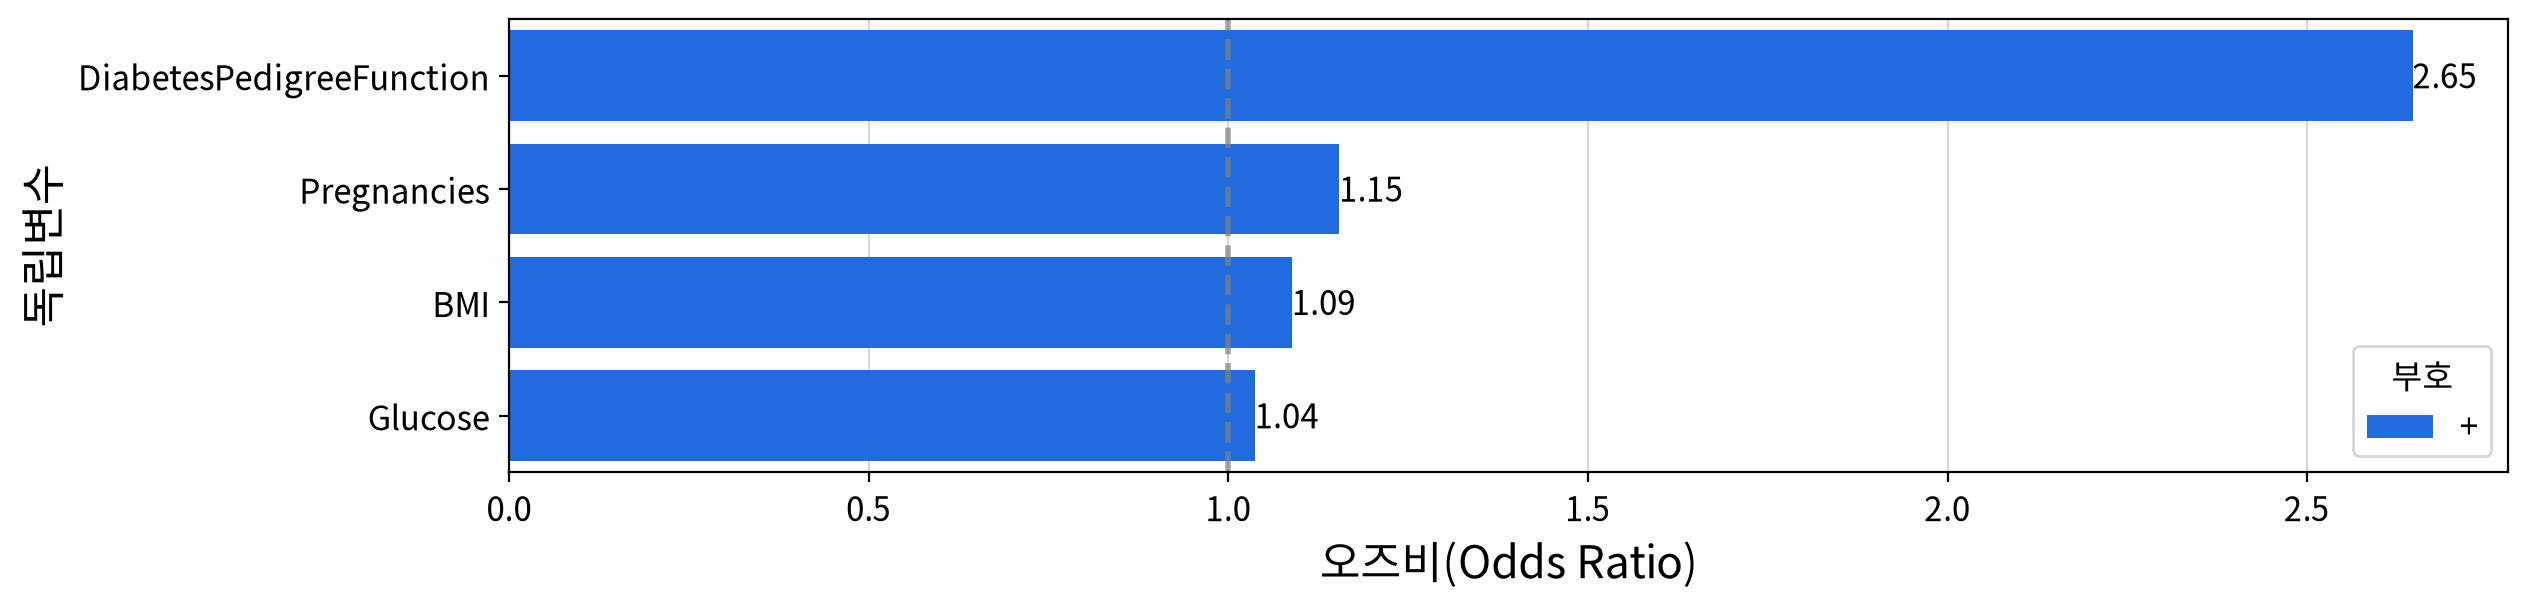

In [16]:
fit = my_logit.auto_logit(df8, y='Outcome', backward=True)

#### 1. 원서 자료를 그대로 넣으면 종속변수가 두 값이 아니라는 이유로 분석이 성립하지 않습니다. 결과가 확정되지 않은 지원자를 걷어내고 나면 분석에 쓰이는 관측치는 몇 개가 되나요?
**정답** 377개 
#### 2. 네 개의 원서 항목을 모두 넣은 기준선 모형에서, 다른 항목을 함께 고려하면 합격 여부를 가장 설명하지 못하는 것으로 나타나 가장 먼저 소거되는 항목은 무엇인가요?
**정답** 성별
#### 3. 필기시험 점수는 당연히 합격을 가를 것 같지만 최종 모형에서는 빠집니다. 필기점수가 소거되는 시점의 유의확률은 얼마인가요? (소수 셋째 자리)
**정답**  필기점수 (p = 0.0657)
#### 4. 소거가 끝난 최종 모형이 합격 여부를 얼마나 설명하는지를 나타내는 유사결정계수는 얼마인가요? (소수 셋째 자리)
**정답** 0.073
#### 5. 입학처장이 "학점 1점 차이가 실제로 얼마나 크냐"고 묻습니다. 최종 모형에서 학부성적이 1점 오를 때 합격 오즈는 몇 배가 되나요? (소수 셋째 자리)
**정답** 2.902
#### 6. 입학처장에게 "이것부터 보라"고 단 하나만 짚어 주려 합니다. 값의 범위가 제각각인 항목들을 같은 잣대로 맞춰 비교했을 때, 합격 여부에 가장 큰 영향을 주는 항목은 무엇인가요?
**정답** 병원경력
#### 7. "학부성적 3.8, 병원경력 1년"인 지원자가 합격 가능성을 문의해 왔습니다. 최종 모형으로 계산한 이 지원자의 합격 확률은 얼마인가요? (소수 셋째 자리)
**정답** 0.629

In [17]:
# 데이터 불러오기
q = load_data('nursing_grades')
q.head()

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터(메타데이터 없음)


,접수코드,이름,성별,필기점수,학부성적,병원경력,합격여부
0,NRS0001,장은우,남,380,3.610,3,불합격
1,NRS0002,최지호,남,660,3.670,3,합격
2,NRS0003,김하준,남,800,4.000,1,합격
3,NRS0004,임아윤,여,640,3.190,4,합격
4,NRS0005,강하준,남,520,2.930,4,불합격


In [18]:
# 중복행 확인
q1 = my_qtcheck.check_duplicates(q)
# 범주형 데이터
q2 = my_qtcheck.set_type(q1, as_category=['성별','합격여부'])
q2
# 결측행 확인
q3 = my_qtcheck.check_missing_values(q2)
q3
# 기초통계량 확인
desc = my_qtcheck.numerical_summary(q2).T
desc

중복된 행의 수: 0
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   접수코드    400 non-null    str     
 1   이름      400 non-null    str     
 2   성별      400 non-null    category
 3   필기점수    400 non-null    int64   
 4   학부성적    400 non-null    float64 
 5   병원경력    400 non-null    int64   
 6   합격여부    400 non-null    category
dtypes: category(2), float64(1), int64(2), str(2)
memory usage: 22.9 KB


,필기점수,학부성적,병원경력
count,400.000,400.000,400.000
mean,587.700,3.390,2.485
std,115.517,0.381,0.944
min,220.000,2.260,1.000
25%,520.000,3.130,2.000
50%,580.000,3.395,2.000
75%,660.000,3.670,3.000
max,800.000,4.000,4.000
rel_diff,0.013,0.002,0.242
rdiff_flag,similar,similar,diff


In [19]:
# 범주형 변수 확인
my_qtcheck.categorical_summary(q2, columns=['성별', '합격여부'])

📊 컬럼 '성별'의 value_counts():


,count
성별,
남,194
여,206


📊 컬럼 '합격여부'의 value_counts():


,count
합격여부,
보류,23
불합격,250
합격,127


,성별,합격여부
count,400,400
unique,2,3
top,여,불합격
freq,206,250


In [20]:
# 합격여부 컬럼에서 보류 행 제거 
q4 = q2[q2['합격여부'] != '보류'].reset_index(drop=True)
# 필요없는 컬럼 제거
q5 = q4.drop(columns=['접수코드', '이름'])
len(q5)
q5.head()

,성별,필기점수,학부성적,병원경력,합격여부
0,남,380,3.610,3,불합격
1,남,660,3.670,3,합격
2,남,800,4.000,1,합격
3,여,640,3.190,4,합격
4,남,520,2.930,4,불합격


In [21]:
# 범주형 라벨링
q6 = my_prep.labeling(q5, columns=['성별', '합격여부'])
q6.head()

성별 (2종): 남=0, 여=1
합격여부 (2종): 불합격=0, 합격=1


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0


In [22]:
# 다중공선성 검사 및 제거
xname = ['성별', '필기점수', '학부성적', '병원경력']


q7 = my_prep.reduce_vif(q6, columns=xname)
q7


완료! 남은 변수: ['병원경력', '성별', '필기점수', '학부성적']
최대VIF = 1.19


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0
...,...,...,...,...,...
372,1,620,4.000,2,0
373,1,560,3.040,3,0
374,1,460,2.630,2,0
375,1,700,3.650,2,0



유의하지 않은 독립변수 제거 → 성별 (p = 0.4769)
유의하지 않은 독립변수 제거 → 필기점수 (p = 0.0657)


#### ▶ 모형 적합도

**Note. n =377. LL = -223.297, LL-Null = -240.879, LLR χ² (2) = 35.164, p < 0.001, Pseudo R² =0.073**

합격여부를 종속변수로, 학부성적, 병원경력(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(2) = 35.164, p < 0.001, Pseudo R² = 0.073.

즉, 모형의 유사결정계수는 0.073로 다소 낮은 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다.일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

#### ▶ 독립변수 보고

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,합격여부,학부성적,1.065,0.411,0.308,3.458,0.001,2.902,1.587,5.307,0.996,1.004
1,합격여부,병원경력,-0.571,-0.536,0.129,-4.429,0.000,0.565,0.439,0.727,0.996,1.004


- **학부성적**의 회귀계수는 **B = 1.0653**, 오즈비는 **OR = 2.9017**로 나타났으며,이는 **합격여부**에 유의한 요인임을 의미한다. (**z = 3.46**, **p < .001**) 즉, **학부성적**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **190.2%****증가**하는 것으로 해석된다.
- **병원경력**의 회귀계수는 **B = -0.5709**, 오즈비는 **OR = 0.565**로 나타났으며,이는 **합격여부**에 유의한 요인임을 의미한다. (**z = -4.43**, **p < .001**) 즉, **병원경력**가 1 증가할 때 합격여부가 1(사건 발생)이 될 오즈는 평균적으로 약 **43.5%****감소**하는 것으로 해석된다.

? ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

#### ▶ 오즈비 시각화

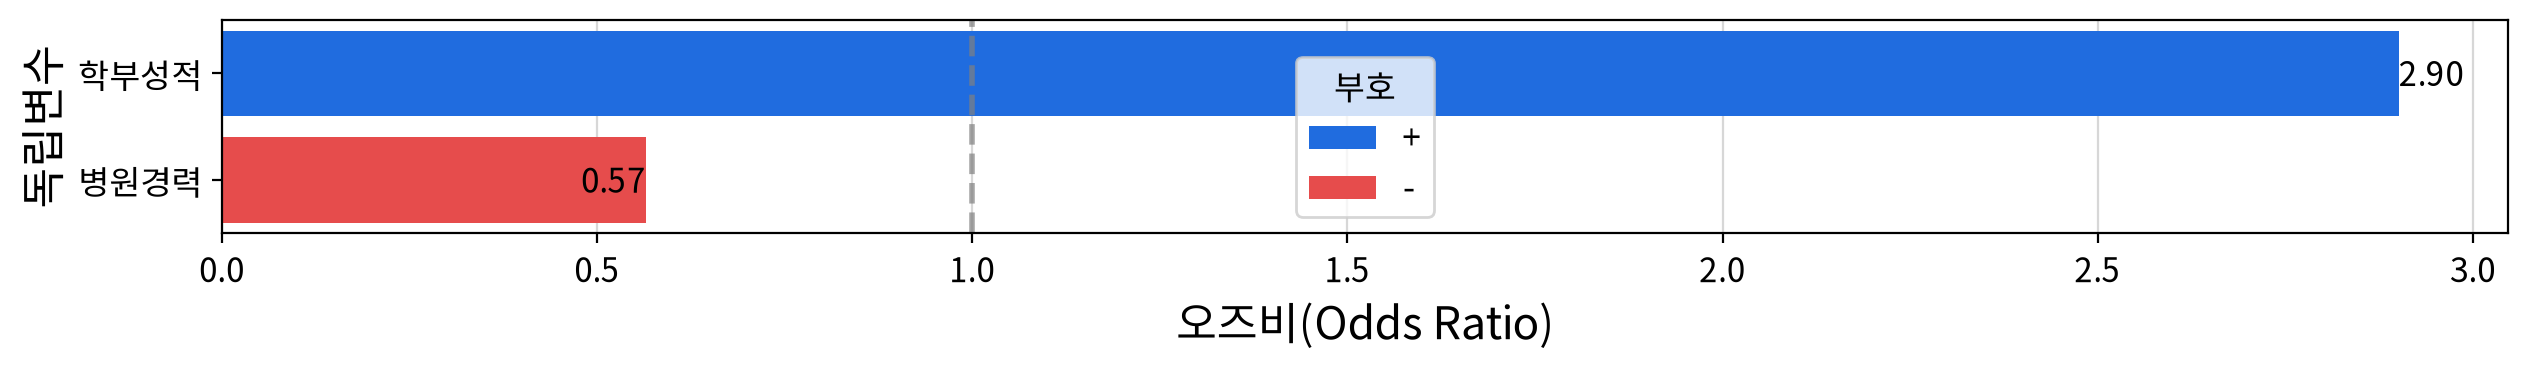

In [23]:
fit = my_logit.auto_logit(q7, y='합격여부', backward=True)


In [25]:
from pandas import DataFrame
new_data = DataFrame({
    '학부성적' : [3.8, 3.7, 3.6, 3.5] ,
    '병원경력' : [1, 4, 1, 2],
})

my_logit.predict(fit,new_data)

,proba,pred
0,0.629,1
1,0.215,0
2,0.578,1
3,0.410,0
